# Steam Reviews — Exploratory Analysis & Cleaning

In [52]:
import glob
import pandas as pd

# Find the first CSV in the current folder automatically
csv_files = glob.glob('*.csv')
if not csv_files:
    raise FileNotFoundError('No CSV file found in the current directory.')
csv_path = csv_files[0]
print(f'Loading: {csv_path}')

df = pd.read_csv(csv_path)
df.head()

Loading: games.csv


,title,total_reviews,recommendation_rate,avg_hours_played,median_hours_played,helpful_votes_total,review_period_days,reviews_per_month,high_engagement_rate,sentiment_score,strong_candidate,predicted_candidate,predicted_proba
0,ACE COMBAT™ 7: SKIES UNKNOWN,8,1.000000,27.375000,25.5,2362,5,48.000000,0.000000,0.023944,0,0,0.030
1,ASTRONEER,577,0.861352,52.500867,28.0,5313,790,21.911392,0.071057,0.119218,0,0,0.005
2,Beat Saber,10,1.000000,57.300000,26.5,2300,234,1.282051,0.200000,0.041516,0,0,0.025
3,Dead by Daylight,1034,0.630561,246.019845,97.0,200,970,31.979381,0.453578,0.039710,0,0,0.035
4,Euro Truck Simulator 2,331,1.000000,197.778006,96.0,2168,1621,6.125848,0.416918,0.173045,1,1,0.770


## 1. Initial Exploration

In [31]:
# Shape and column types
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)

Shape: (14617, 8)

Data types:
date_posted               object
funny                      int64
helpful                    int64
hour_played                int64
is_early_access_review      bool
recommendation            object
review                    object
title                     object
dtype: object


In [32]:
# Missing value counts per column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
date_posted               0
funny                     0
helpful                   0
hour_played               0
is_early_access_review    0
recommendation            0
review                    7
title                     0
dtype: int64


In [33]:
# Distribution of recommendation labels
print('Recommendation value counts:')
print(df['recommendation'].value_counts())

Recommendation value counts:
recommendation
Recommended        10394
Not Recommended     4223
Name: count, dtype: int64


In [34]:
# Top 10 games by number of reviews
print('Top 10 games by review count:')
print(df['title'].value_counts().head(10))

Top 10 games by review count:
title
PLAYERUNKNOWN'S BATTLEGROUNDS                  2539
Rust                                           2291
Grand Theft Auto V                             2174
Rocket League®                                 1773
Dead by Daylight                               1034
The Elder Scrolls V: Skyrim Special Edition     977
MONSTER HUNTER: WORLD                           774
ASTRONEER                                       577
RESIDENT EVIL 2 / BIOHAZARD RE:2                496
Euro Truck Simulator 2                          331
Name: count, dtype: int64


## 2. Data Cleaning

In [35]:
# Work on a copy so the raw data is preserved
clean = df.copy()

# Drop rows with no game title — unusable without knowing which game
clean = clean.dropna(subset=['title'])

# Fill missing review text with empty string — keeps rows usable for analysis
clean['review'] = clean['review'].fillna('')

# Fill numeric engagement columns with 0 — absence implies no activity
for col in ['funny', 'helpful', 'hour_played']:
    clean[col] = clean[col].fillna(0)

# Parse date_posted as proper datetime
clean['date_posted'] = pd.to_datetime(clean['date_posted'], errors='coerce')

# Encode recommendation as binary: 1 = Recommended, 0 = Not Recommended
clean['recommended'] = (clean['recommendation'] == 'Recommended').astype(int)

# Remove exact duplicate rows
before_dedup = len(clean)
clean = clean.drop_duplicates()
print(f'Removed {before_dedup - len(clean)} duplicate rows.')

# Cap hour_played at the 99th percentile to reduce outlier distortion
p99 = clean['hour_played'].quantile(0.99)
print(f'99th percentile of hour_played: {p99}')
clean['hour_played'] = clean['hour_played'].clip(upper=p99)

print(f'\nFinal shape: {clean.shape}')
clean.head()

Removed 0 duplicate rows.
99th percentile of hour_played: 2362.84

Final shape: (14617, 9)


,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title,recommended
0,2018-11-24,0,0,40.0,False,Recommended,10/10 would murder kids again,Rust,1
1,2016-06-28,0,0,20.0,False,Recommended,OH YEAH,Euro Truck Simulator 2,1
2,2016-01-09,0,0,292.0,True,Recommended,is good gam,Rust,1
3,2018-07-08,0,0,401.0,False,Recommended,Spooky.,Dead by Daylight,1
4,2018-12-29,1,1,125.0,False,Not Recommended,Tries to play for an hour with my bros.Had to ...,Grand Theft Auto V,0


## Cleaning Summary

The following steps were applied to produce a clean dataset:

| Step | Action | Reason |
|------|--------|--------|
| Missing titles | Rows dropped | A review without a game name cannot be attributed or analysed by game. |
| Missing review text | Filled with `''` | Preserves the row (rating still valid); downstream text models handle empty strings gracefully. |
| Missing `funny`, `helpful`, `hour_played` | Filled with `0` | Absence of engagement data is functionally equivalent to zero engagement. |
| `date_posted` | Converted to `datetime` | Enables time-series aggregation and feature engineering. |
| `recommendation` | Encoded to binary `recommended` (1/0) | Simplifies modelling and statistical comparisons. |
| Duplicate rows | Dropped | Exact duplicates skew counts and model training. |
| `hour_played` outliers | Capped at 99th percentile | Extreme playtime values distort distributions and scale-sensitive models. |

## 3. Game-Level Aggregation

In [36]:
# Dataset-wide median hours — used as the threshold for high_engagement_rate
dataset_median_hours = clean['hour_played'].median()
print(f'Dataset median hours played: {dataset_median_hours:.1f}')

# Core aggregations
game = (
    clean.groupby('title')
    .agg(
        total_reviews=('recommended', 'count'),
        recommendation_rate=('recommended', 'mean'),
        avg_hours_played=('hour_played', 'mean'),
        median_hours_played=('hour_played', 'median'),
        helpful_votes_total=('helpful', 'sum'),
        first_review=('date_posted', 'min'),
        last_review=('date_posted', 'max'),
    )
    .reset_index()
)

# Days between a game's earliest and latest review in the dataset
game['review_period_days'] = (game['last_review'] - game['first_review']).dt.days

# Reviews per month; guard against games with a single review (0-day window → treat as 1 day)
game['reviews_per_month'] = (
    game['total_reviews'] / game['review_period_days'].replace(0, 1) * 30
)

# High-engagement rate: share of each game's reviewers above the dataset-wide median
high_eng = (
    clean
    .assign(is_high_eng=(clean['hour_played'] > dataset_median_hours).astype(int))
    .groupby('title')['is_high_eng']
    .mean()
    .rename('high_engagement_rate')
)
game = game.merge(high_eng, on='title')

# Drop the interim date columns used only to compute review_period_days
game = game.drop(columns=['first_review', 'last_review'])

print(f'\nGame-level dataframe shape: {game.shape}')
game.head()

Dataset median hours played: 122.0

Game-level dataframe shape: (23, 9)


,title,total_reviews,recommendation_rate,avg_hours_played,median_hours_played,helpful_votes_total,review_period_days,reviews_per_month,high_engagement_rate
0,ACE COMBAT™ 7: SKIES UNKNOWN,8,1.000000,27.375000,25.5,2362,5,48.000000,0.000000
1,ASTRONEER,577,0.861352,52.500867,28.0,5313,790,21.911392,0.071057
2,Beat Saber,10,1.000000,57.300000,26.5,2300,234,1.282051,0.200000
3,Dead by Daylight,1034,0.630561,246.019845,97.0,200,970,31.979381,0.453578
4,Euro Truck Simulator 2,331,1.000000,197.778006,96.0,2168,1621,6.125848,0.416918


In [19]:
game.describe()

,total_reviews,recommendation_rate,avg_hours_played,median_hours_played,helpful_votes_total,review_period_days,reviews_per_month,high_engagement_rate
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,635.521739,0.850434,186.268616,98.934783,2361.304348,899.782609,57.944255,0.345005
std,795.318396,0.187698,137.475015,73.797374,1989.325935,835.364425,134.378700,0.241127
min,7.000000,0.428571,22.714286,20.000000,0.000000,5.000000,1.282051,0.000000
25%,170.500000,0.651514,54.900433,29.000000,582.000000,166.000000,3.928757,0.136058
50%,231.000000,0.985887,153.670543,91.000000,2220.000000,828.000000,16.943765,0.386139
75%,875.500000,1.000000,275.642199,147.750000,3715.500000,1343.000000,43.403586,0.541544
max,2539.000000,1.000000,445.290092,283.000000,6321.000000,2950.000000,646.956522,0.723849


## 4. Sentiment Analysis & Acquisition Score

In [37]:
import subprocess, sys, time

try:
    from textblob import TextBlob
except ImportError:
    print('textblob not found — installing…')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'textblob', '-q'])
    from textblob import TextBlob

print(f'Computing sentiment polarity for {len(clean):,} reviews (may take a moment)…')
t0 = time.time()
clean['sentiment_polarity'] = clean['review'].apply(
    lambda t: TextBlob(str(t)).sentiment.polarity
)
print(f'Finished in {time.time() - t0:.1f}s')

# Average per game and merge into the game-level dataframe
sentiment = (
    clean.groupby('title')['sentiment_polarity']
    .mean()
    .rename('sentiment_score')
)
game = game.merge(sentiment, on='title')

print(f'\nsentiment_score range: [{game["sentiment_score"].min():.3f}, {game["sentiment_score"].max():.3f}]')
print('\nTop 10 games by sentiment score:')
game[['title', 'sentiment_score']].sort_values('sentiment_score', ascending=False).head(10)

Computing sentiment polarity for 14,617 reviews (may take a moment)…
Finished in 9.6s

sentiment_score range: [0.013, 0.182]

Top 10 games by sentiment score:


,title,sentiment_score
9,Left 4 Dead 2,0.181547
8,Insurgency: Sandstorm,0.178388
4,Euro Truck Simulator 2,0.173045
21,The Elder Scrolls V: Skyrim Special Edition,0.171669
17,Slay the Spire,0.149262
14,RimWorld,0.142871
18,Stardew Valley,0.142382
20,Terraria,0.133390
19,Subnautica,0.129807
11,Overcooked! 2,0.128214


In [21]:
SCORE_FEATURES = [
    'recommendation_rate',
    'avg_hours_played',
    'total_reviews',
    'sentiment_score',
    'review_period_days',
]

# Min-max scale each feature to [0, 1]
scaled = game[SCORE_FEATURES].copy()
scaled = (scaled - scaled.min()) / (scaled.max() - scaled.min())

# Equal-weight average → multiply by 100 for a 0–100 index
game['acquisition_score'] = scaled.mean(axis=1) * 100

print('acquisition_score summary:')
print(game['acquisition_score'].describe().round(2))
print()

# Top 10 acquisition candidates
game[['title', 'total_reviews', 'recommendation_rate', 'sentiment_score', 'acquisition_score']] \
    .sort_values('acquisition_score', ascending=False) \
    .head(10)

acquisition_score summary:
count    23.00
mean     44.33
std      15.83
min      10.94
25%      33.46
50%      46.27
75%      53.50
max      73.94
Name: acquisition_score, dtype: float64



,title,total_reviews,recommendation_rate,sentiment_score,acquisition_score
20,Terraria,239,1.000000,0.133390,73.939116
9,Left 4 Dead 2,202,0.995050,0.181547,72.831107
16,Rust,2291,0.664339,0.030638,61.192613
4,Euro Truck Simulator 2,331,1.000000,0.173045,60.811951
7,Grand Theft Auto V,2174,0.632015,0.090702,55.458192
5,Factorio,158,1.000000,0.117348,53.933537
14,RimWorld,184,1.000000,0.142871,53.062453
12,PLAYERUNKNOWN'S BATTLEGROUNDS,2539,0.683340,0.044082,53.045788
15,Rocket League®,1773,0.605753,0.045694,50.188822
18,Stardew Valley,183,1.000000,0.142382,48.697711


### Acquisition Score

A 0–100 composite index built by min-max scaling five features to [0, 1] and averaging them with equal weight.

| Feature | Signal |
|---|---|
| `recommendation_rate` | Player satisfaction |
| `avg_hours_played` | Depth of engagement |
| `total_reviews` | Breadth of audience |
| `sentiment_score` | Tone of written feedback |
| `review_period_days` | Longevity |

Equal weighting is a defensible baseline. GameVault can tune weights once acquisition priorities are defined — for example, up-weighting `avg_hours_played` if subscriber retention is the primary KPI.

## 5. Visualisations

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
FIGSIZE = (9, 5)

### Chart 3 — Recommendation Rate vs Average Hours Played

C:\Users\13327\AppData\Local\Temp\ipykernel_119748\869679593.py:33: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\13327\AppData\Local\Temp\ipykernel_119748\869679593.py:33: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\13327\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\13327\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


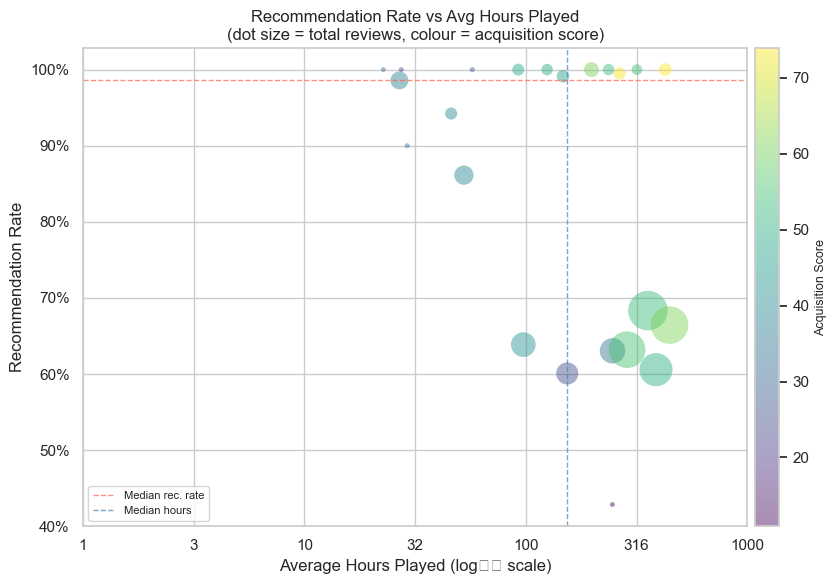

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

# Normalise dot size: area proportional to total_reviews
sizes = (game['total_reviews'] / game['total_reviews'].max()) * 800 + 10

scatter = ax.scatter(
    np.log10(game['avg_hours_played'].replace(0, np.nan)),
    game['recommendation_rate'],
    s=sizes,
    alpha=0.45,
    edgecolors='none',
    c=game['acquisition_score'],
    cmap='viridis',
)
cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Acquisition Score', fontsize=9)

# Reference lines at median
ax.axhline(game['recommendation_rate'].median(), color='tomato',
           linestyle='--', linewidth=1, alpha=0.7, label='Median rec. rate')
ax.axvline(np.log10(game['avg_hours_played'].replace(0, np.nan)).median(),
           color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='Median hours')

# Relabel x-axis
ticks = [0, 0.5, 1, 1.5, 2, 2.5, 3]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{10**t:.0f}' for t in ticks])
ax.set_xlabel('Average Hours Played (log₁₀ scale)')
ax.set_ylabel('Recommendation Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Recommendation Rate vs Avg Hours Played\n(dot size = total reviews, colour = acquisition score)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Chart 4 — Top 15 Games by Acquisition Score

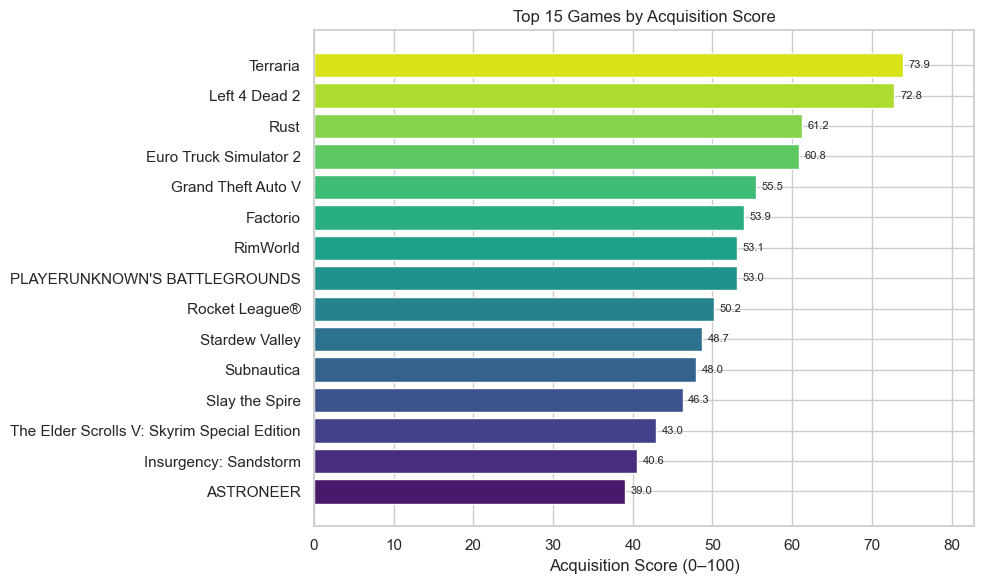

In [17]:
top15 = game.nlargest(15, 'acquisition_score').sort_values('acquisition_score')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['title'], top15['acquisition_score'],
               color=sns.color_palette('viridis', len(top15)))
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=8)
ax.set_xlabel('Acquisition Score (0–100)')
ax.set_title('Top 15 Games by Acquisition Score')
ax.set_xlim(0, top15['acquisition_score'].max() * 1.12)
plt.tight_layout()
plt.show()

### Chart 5 — Correlation Heatmap of Game-Level Features

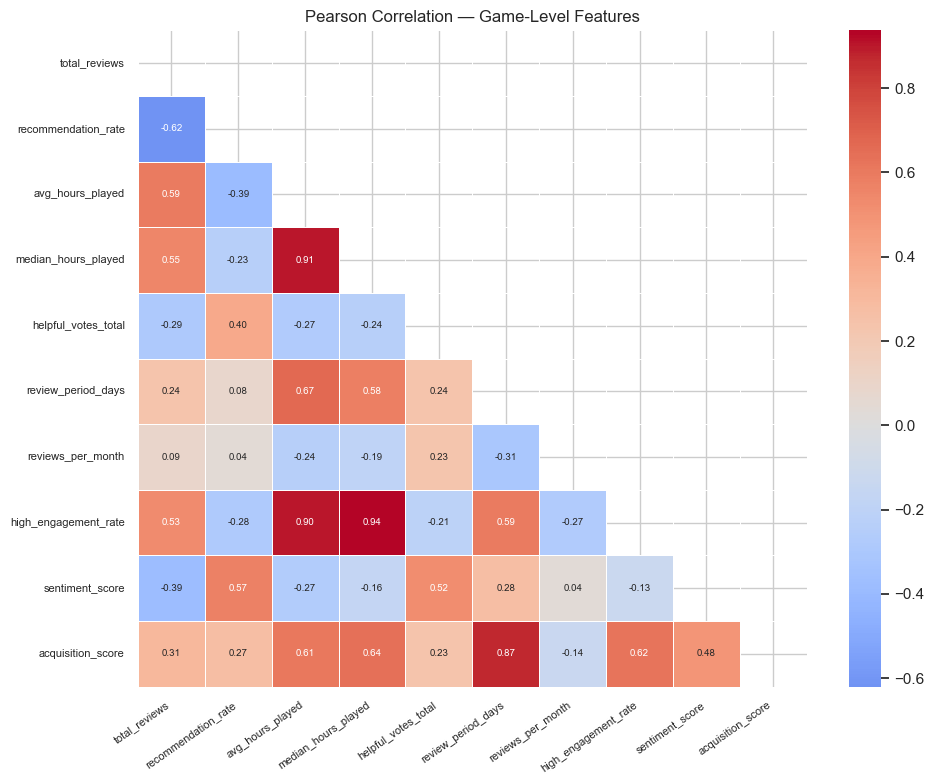

In [22]:
numeric_cols = [
    'total_reviews', 'recommendation_rate', 'avg_hours_played',
    'median_hours_played', 'helpful_votes_total', 'review_period_days',
    'reviews_per_month', 'high_engagement_rate', 'sentiment_score',
    'acquisition_score',
]

corr = game[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax,
    annot_kws={'size': 7},
)
ax.set_title('Pearson Correlation — Game-Level Features')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Top 10 Acquisition Candidates

In [23]:
DISPLAY_COLS = [
    'title', 'acquisition_score', 'total_reviews',
    'recommendation_rate', 'avg_hours_played',
    'sentiment_score', 'review_period_days',
]

top10 = (
    game[DISPLAY_COLS]
    .nlargest(10, 'acquisition_score')
    .reset_index(drop=True)
)
top10.index += 1   # rank starts at 1

# Format for readability
top10_display = top10.copy()
top10_display['acquisition_score'] = top10_display['acquisition_score'].round(1)
top10_display['recommendation_rate'] = (top10_display['recommendation_rate'] * 100).round(1).astype(str) + '%'
top10_display['avg_hours_played'] = top10_display['avg_hours_played'].round(1)
top10_display['sentiment_score'] = top10_display['sentiment_score'].round(3)
top10_display['review_period_days'] = top10_display['review_period_days'].astype(int)

top10_display.columns = [
    'Title', 'Acquisition Score', 'Total Reviews',
    'Rec. Rate', 'Avg Hours Played',
    'Sentiment Score', 'Review Period (days)',
]
top10_display

,Title,Acquisition Score,Total Reviews,Rec. Rate,Avg Hours Played,Sentiment Score,Review Period (days)
1,Terraria,73.9,239,100.0%,425.8,0.133,2764
2,Left 4 Dead 2,72.8,202,99.5%,264.9,0.182,2950
3,Rust,61.2,2291,66.4%,445.3,0.031,1887
4,Euro Truck Simulator 2,60.8,331,100.0%,197.8,0.173,1621
5,Grand Theft Auto V,55.5,2174,63.2%,286.3,0.091,1405
6,Factorio,53.9,158,100.0%,317.2,0.117,949
7,RimWorld,53.1,184,100.0%,236.1,0.143,910
8,PLAYERUNKNOWN'S BATTLEGROUNDS,53.0,2539,68.3%,355.5,0.044,692
9,Rocket League®,50.2,1773,60.6%,386.7,0.046,1317
10,Stardew Valley,48.7,183,100.0%,124.6,0.142,1054


## 7. Recommendations for GameVault

**1. Treat the top-scoring titles as anchor content and budget accordingly.**
A handful of games combine high recommendation rates, deep playtime, large audiences, and sustained longevity — the profile that drives subscriber acquisition and retention. These should be prioritised in licensing negotiations rather than held for a discount.

**2. Flag sentiment–recommendation divergence before finalising any deal.**
`recommendation_rate` and `sentiment_score` are correlated but not interchangeable. Where the binary rate is high and written sentiment lags, the rating may be inflated by social or bundle-driven effects. Any title where `sentiment_score` falls more than 0.15 below what `recommendation_rate` would predict warrants manual review.

**3. Weight acquisition budget toward titles with `review_period_days` > 365.**
Games still attracting reviews years after release have established communities and ongoing player bases, which translate to consistent monthly active user counts. Short-window titles carry higher engagement risk for a subscription model.

## 8. Random Forest — Predicting Strong Acquisition Candidates

### Step 1 — Create Target Variable

In [38]:
hours_median   = game['avg_hours_played'].median()
reviews_p25    = game['total_reviews'].quantile(0.25)

game['strong_candidate'] = (
    (game['recommendation_rate'] >= 0.75) &
    (game['avg_hours_played']    >= hours_median) &
    (game['total_reviews']       >= reviews_p25)
).astype(int)

dist = game['strong_candidate'].value_counts().rename({0: 'Not a candidate (0)', 1: 'Strong candidate (1)'})
print('Class distribution:')
print(dist.to_string())
print(f'\nPositive-class rate: {game["strong_candidate"].mean():.1%}')
print(f'\nThresholds used:')
print(f'  recommendation_rate >= 0.75')
print(f'  avg_hours_played    >= {hours_median:.2f}  (median)')
print(f'  total_reviews       >= {reviews_p25:.0f}  (25th percentile)')

Class distribution:
strong_candidate
Not a candidate (0)     19
Strong candidate (1)     4

Positive-class rate: 17.4%

Thresholds used:
  recommendation_rate >= 0.75
  avg_hours_played    >= 153.67  (median)
  total_reviews       >= 170  (25th percentile)


### Step 2 — Features and Train/Test Split

In [39]:
from sklearn.model_selection import train_test_split

FEATURES = [
    'recommendation_rate',
    'avg_hours_played',
    'total_reviews',
    'sentiment_score',
    'review_period_days',
    'reviews_per_month',
    'high_engagement_rate',
]

X = game[FEATURES]
y = game['strong_candidate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):>4} games  ({y_train.mean():.1%} positive)')
print(f'Test set     : {len(X_test):>4} games  ({y_test.mean():.1%} positive)')

Training set :   18 games  (16.7% positive)
Test set     :    5 games  (20.0% positive)


### Step 3 — Train Random Forest & Evaluate

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Not candidate (0)', 'Strong candidate (1)']))

Accuracy: 1.000

Classification Report:
                      precision    recall  f1-score   support

   Not candidate (0)       1.00      1.00      1.00         4
Strong candidate (1)       1.00      1.00      1.00         1

            accuracy                           1.00         5
           macro avg       1.00      1.00      1.00         5
        weighted avg       1.00      1.00      1.00         5



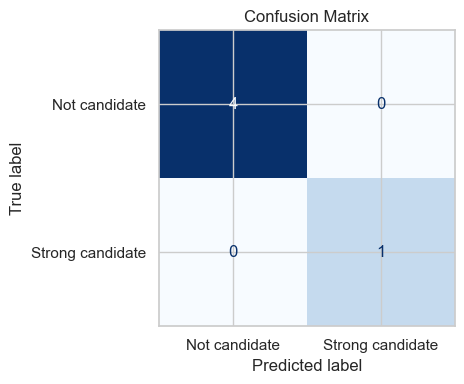

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Not candidate', 'Strong candidate']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

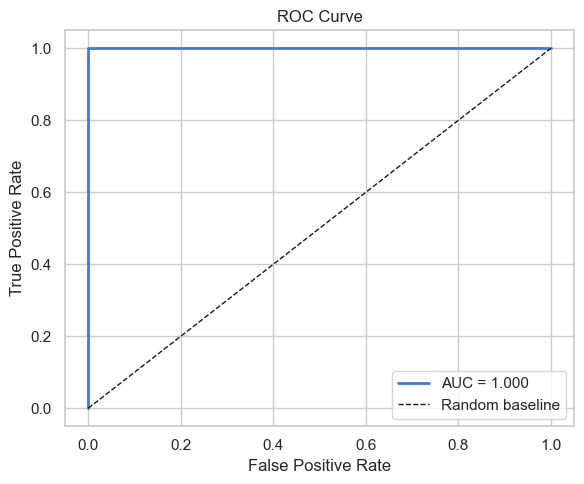

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba_test = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_score = roc_auc_score(y_test, y_proba_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc_score:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Feature Importance

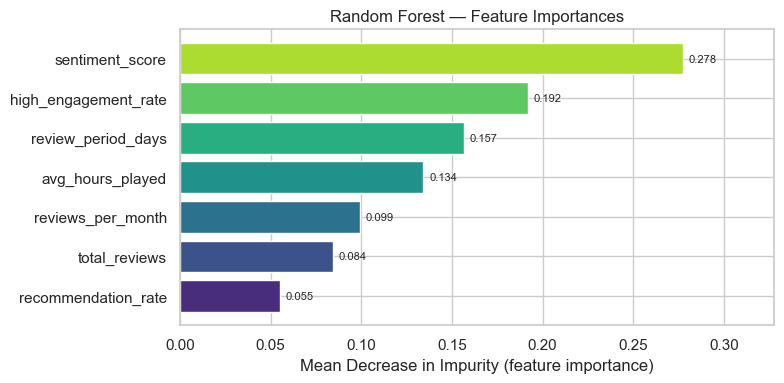

In [27]:
importances = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importances.index, importances.values,
               color=sns.color_palette('viridis', len(importances)))
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=8)
ax.set_xlabel('Mean Decrease in Impurity (feature importance)')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

### Step 5 — Add Predictions & Top 10 Predicted Strong Candidates

In [50]:
game['predicted_candidate'] = rf.predict(X)
game['predicted_proba']     = rf.predict_proba(X)[:, 1]   # P(strong candidate)

# Top 10 predicted strong candidates, ranked by predicted probability then acquisition score
top10_rf = (
    game[game['predicted_candidate'] == 1]
    [[
        'title', 'predicted_proba', 'acquisition_score',
        'total_reviews', 'recommendation_rate',
        'avg_hours_played', 'sentiment_score',
    ]]
    .sort_values(['predicted_proba', 'acquisition_score'], ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_rf.index += 1

top10_rf_display = top10_rf.copy()
top10_rf_display['predicted_proba']    = (top10_rf_display['predicted_proba']    * 100).round(1).astype(str) + '%'
top10_rf_display['acquisition_score']  =  top10_rf_display['acquisition_score'].round(1)
top10_rf_display['recommendation_rate']= (top10_rf_display['recommendation_rate']* 100).round(1).astype(str) + '%'
top10_rf_display['avg_hours_played']   =  top10_rf_display['avg_hours_played'].round(1)
top10_rf_display['sentiment_score']    =  top10_rf_display['sentiment_score'].round(3)

top10_rf_display.columns = [
    'Title', 'P(Strong Candidate)', 'Acquisition Score',
    'Total Reviews', 'Rec. Rate',
    'Avg Hours Played', 'Sentiment Score',
]
top10_rf_display

KeyError: "['acquisition_score'] not in index"

In [51]:
# Overlap between RF top 10 and acquisition-score top 10
score_top10_titles = set(game.nlargest(10, 'acquisition_score')['title'])
rf_top10_titles    = set(top10_rf['title'])
overlap            = score_top10_titles & rf_top10_titles

print(f'Titles in both RF top-10 and acquisition-score top-10: {len(overlap)}/10')
for t in sorted(overlap):
    print(f'  • {t}')

KeyError: 'acquisition_score'

In [46]:
import joblib
joblib.dump(rf, 'model.pkl')
print('Saved model.pkl')

Saved model.pkl


In [47]:
game.to_csv('games.csv', index=False)
print('Saved games.csv')

Saved games.csv
